# 04 Network and path analysis

This notebook reconstructs the W/O genotype network used for landscape and path-based analyses.

The workflow starts from the processed W/O landscape table and builds an 8-dimensional genotype graph where each genotype is connected to all one-mutation W/O neighbors.

This notebook focuses on network/path analyses derived from genotype-level enrichment metrics such as `ddelta`, `log2fc_pos_pre`, and `log2fc_neg_pre`.

Collaborator/model-comparison analyses are handled separately.

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "figures" / "network_path"
CONFIG_PATH = PROJECT_ROOT / "config" / "analysis_config.yml"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

EPSILON = float(config["epsilon"])
MIN_SAMPLE_TOTAL_UMI = int(config["min_sample_total_umi"])

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Checkpoint output:", CHECKPOINT_DIR)
print("Figure output:", FIGURE_DIR)
print("Config path:", CONFIG_PATH)
print("EPSILON:", EPSILON)
print("Configured MIN_SAMPLE_TOTAL_UMI:", MIN_SAMPLE_TOTAL_UMI)

Project root: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape
Processed data: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/data/processed
Checkpoint output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/outputs/checkpoints
Figure output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/figures/network_path
Config path: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/config/analysis_config.yml
EPSILON: 1e-06
Configured MIN_SAMPLE_TOTAL_UMI: 0


In [2]:
landscape = pd.read_csv(PROCESSED_DIR / "WO_landscape_per_library.csv")

print("landscape:", landscape.shape)
print("columns:", list(landscape.columns))

landscape.head()

landscape: (768, 11)
columns: ['library_id', 'wo', 'Neg', 'Pos', 'Pre', 'log2fc_pos_pre', 'log2fc_neg_pre', 'delta_pos', 'delta_neg', 'mut_count', 'ddelta']


,library_id,wo,Neg,Pos,Pre,log2fc_pos_pre,log2fc_neg_pre,delta_pos,delta_neg,mut_count,ddelta
0,1,OOOOOOOO,0.005949,0.008597,0.003254,1.401357,0.870073,0.005343,0.002694,8,0.531285
1,1,OOOOOOOW,0.001347,0.001362,0.001796,-0.398696,-0.414820,-0.000434,-0.000449,7,0.016124
2,1,OOOOOOWO,0.003486,0.001391,0.002819,-1.018301,0.306112,-0.001428,0.000667,7,-1.324413
3,1,OOOOOOWW,0.003220,0.000169,0.004767,-4.807749,-0.565828,-0.004598,-0.001547,6,-4.241921
4,1,OOOOOWOO,0.000682,0.000340,0.000464,-0.450684,0.553312,-0.000125,0.000218,7,-1.003995


In [3]:
assert landscape.shape[0] == 3 * 256, "Expected 3 libraries x 256 genotypes."
assert landscape["wo"].str.len().eq(8).all(), "All W/O genotypes should have length 8."
assert set(landscape["library_id"]) == {1, 2, 3}, "Expected libraries 1, 2, and 3."

coverage = (
    landscape
    .groupby("library_id", as_index=False)
    .agg(
        n_genotypes=("wo", "nunique"),
        n_rows=("wo", "size")
    )
)

assert coverage["n_genotypes"].eq(256).all(), "Each library should contain all 256 genotypes."

coverage

,library_id,n_genotypes,n_rows
0,1,256,256
1,2,256,256
2,3,256,256


In [4]:
def hamming_distance(a: str, b: str) -> int:
    """Return Hamming distance between two equal-length genotype strings."""
    assert len(a) == len(b), "Genotype strings must have equal length."
    return sum(x != y for x, y in zip(a, b))


def one_step_neighbors(genotype: str) -> list[str]:
    """
    Generate all one-step W/O neighbors for an 8-position genotype string.
    """
    neighbors = []
    for i, char in enumerate(genotype):
        if char == "W":
            new_char = "O"
        elif char == "O":
            new_char = "W"
        else:
            raise ValueError(f"Unexpected genotype character: {char}")
        
        neighbor = genotype[:i] + new_char + genotype[i + 1:]
        neighbors.append(neighbor)
    
    return neighbors


# Quick checks
assert hamming_distance("WWWWWWWW", "OWWWWWWW") == 1
assert hamming_distance("WWWWWWWW", "OOOOOOOO") == 8
assert len(one_step_neighbors("WWWWWWWW")) == 8

one_step_neighbors("WWWWWWWW")[:5]

['OWWWWWWW', 'WOWWWWWW', 'WWOWWWWW', 'WWWOWWWW', 'WWWWOWWW']

In [5]:
genotypes = sorted(landscape["wo"].unique())

assert len(genotypes) == 256, "Expected 256 unique W/O genotypes."

genotype_set = set(genotypes)

undirected_edges = []

for genotype in genotypes:
    for neighbor in one_step_neighbors(genotype):
        if neighbor in genotype_set:
            # Sort pair so each undirected edge appears once
            a, b = sorted([genotype, neighbor])
            undirected_edges.append((a, b))

undirected_edges = sorted(set(undirected_edges))

edge_df = pd.DataFrame(undirected_edges, columns=["genotype_a", "genotype_b"])
edge_df["hamming_distance"] = edge_df.apply(
    lambda row: hamming_distance(row["genotype_a"], row["genotype_b"]),
    axis=1
)

assert edge_df["hamming_distance"].eq(1).all(), "All edges should connect one-step neighbors."

edge_df.to_csv(
    CHECKPOINT_DIR / "wo_genotype_undirected_edges.csv",
    index=False
)

print("Number of genotypes:", len(genotypes))
print("Number of undirected one-step edges:", edge_df.shape[0])

edge_df.head()

Number of genotypes: 256
Number of undirected one-step edges: 1024


,genotype_a,genotype_b,hamming_distance
0,OOOOOOOO,OOOOOOOW,1
1,OOOOOOOO,OOOOOOWO,1
2,OOOOOOOO,OOOOOWOO,1
3,OOOOOOOO,OOOOWOOO,1
4,OOOOOOOO,OOOWOOOO,1


In [6]:
def mut_count(genotype: str) -> int:
    return genotype.count("O")


load_directed_edges = []

for genotype_a, genotype_b in undirected_edges:
    load_a = mut_count(genotype_a)
    load_b = mut_count(genotype_b)
    
    if load_a < load_b:
        source, target = genotype_a, genotype_b
    elif load_b < load_a:
        source, target = genotype_b, genotype_a
    else:
        # Should not happen for one-step W/O neighbors
        continue
    
    load_directed_edges.append({
        "source": source,
        "target": target,
        "source_mut_count": mut_count(source),
        "target_mut_count": mut_count(target),
        "delta_mut_count": mut_count(target) - mut_count(source),
    })

load_edge_df = pd.DataFrame(load_directed_edges)

assert load_edge_df["delta_mut_count"].eq(1).all(), (
    "All load-directed edges should increase mutational load by 1."
)

load_edge_df.to_csv(
    CHECKPOINT_DIR / "wo_genotype_load_directed_edges.csv",
    index=False
)

print("Number of load-directed edges:", load_edge_df.shape[0])
load_edge_df.head()

Number of load-directed edges: 1024


,source,target,source_mut_count,target_mut_count,delta_mut_count
0,OOOOOOOW,OOOOOOOO,7,8,1
1,OOOOOOWO,OOOOOOOO,7,8,1
2,OOOOOWOO,OOOOOOOO,7,8,1
3,OOOOWOOO,OOOOOOOO,7,8,1
4,OOOWOOOO,OOOOOOOO,7,8,1


In [7]:
def compute_uphill_edges(
    landscape_df: pd.DataFrame,
    directed_edges: pd.DataFrame,
    value_col: str
) -> pd.DataFrame:
    """
    For each library, evaluate load-directed edges and classify whether
    the edge is uphill in the selected value column.
    """
    rows = []
    
    for library_id, sub in landscape_df.groupby("library_id"):
        value_map = sub.set_index("wo")[value_col].to_dict()
        
        for _, edge in directed_edges.iterrows():
            source = edge["source"]
            target = edge["target"]
            
            source_value = value_map[source]
            target_value = value_map[target]
            edge_delta = target_value - source_value
            
            rows.append({
                "library_id": library_id,
                "metric": value_col,
                "source": source,
                "target": target,
                "source_mut_count": edge["source_mut_count"],
                "target_mut_count": edge["target_mut_count"],
                "source_value": source_value,
                "target_value": target_value,
                "edge_delta": edge_delta,
                "is_uphill": edge_delta > 0,
            })
    
    return pd.DataFrame(rows)


metrics_to_analyze = [
    "log2fc_pos_pre",
    "log2fc_neg_pre",
    "ddelta",
]

uphill_edge_tables = []

for metric in metrics_to_analyze:
    uphill_edge_tables.append(
        compute_uphill_edges(
            landscape,
            load_edge_df,
            value_col=metric
        )
    )

uphill_edges = pd.concat(uphill_edge_tables, ignore_index=True)

uphill_edges.to_csv(
    CHECKPOINT_DIR / "wo_genotype_uphill_edges_by_metric.csv",
    index=False
)

uphill_edges.head()

,library_id,metric,source,target,source_mut_count,target_mut_count,source_value,target_value,edge_delta,is_uphill
0,1,log2fc_pos_pre,OOOOOOOW,OOOOOOOO,7,8,-0.398696,1.401357,1.800054,True
1,1,log2fc_pos_pre,OOOOOOWO,OOOOOOOO,7,8,-1.018301,1.401357,2.419658,True
2,1,log2fc_pos_pre,OOOOOWOO,OOOOOOOO,7,8,-0.450684,1.401357,1.852041,True
3,1,log2fc_pos_pre,OOOOWOOO,OOOOOOOO,7,8,0.412662,1.401357,0.988695,True
4,1,log2fc_pos_pre,OOOWOOOO,OOOOOOOO,7,8,-2.542318,1.401357,3.943675,True


In [8]:
uphill_edge_summary = (
    uphill_edges
    .groupby(["library_id", "metric"], as_index=False)
    .agg(
        n_edges=("is_uphill", "size"),
        n_uphill_edges=("is_uphill", "sum"),
        mean_edge_delta=("edge_delta", "mean"),
        median_edge_delta=("edge_delta", "median"),
        min_edge_delta=("edge_delta", "min"),
        max_edge_delta=("edge_delta", "max"),
    )
)

uphill_edge_summary["fraction_uphill"] = (
    uphill_edge_summary["n_uphill_edges"] /
    uphill_edge_summary["n_edges"]
)

uphill_edge_summary.to_csv(
    CHECKPOINT_DIR / "wo_genotype_uphill_edge_summary.csv",
    index=False
)

uphill_edge_summary

,library_id,metric,n_edges,n_uphill_edges,mean_edge_delta,median_edge_delta,min_edge_delta,max_edge_delta,fraction_uphill
0,1,ddelta,1024,547,0.089864,0.113757,-5.603798,8.279896,0.534180
1,1,log2fc_neg_pre,1024,557,0.111825,0.091155,-3.740964,4.468863,0.543945
2,1,log2fc_pos_pre,1024,557,0.201690,0.132386,-5.272580,7.055097,0.543945
3,2,ddelta,1024,538,0.206261,0.091922,-5.800554,10.749117,0.525391
4,2,log2fc_neg_pre,1024,512,-0.009990,-0.001791,-3.386790,3.713607,0.500000
5,2,log2fc_pos_pre,1024,558,0.196271,0.098367,-4.660886,8.561412,0.544922
6,3,ddelta,1024,527,0.073469,0.068292,-5.523818,5.983835,0.514648
7,3,log2fc_neg_pre,1024,537,0.085620,0.074865,-5.111970,5.772508,0.524414
8,3,log2fc_pos_pre,1024,580,0.159089,0.150560,-2.931914,2.932359,0.566406


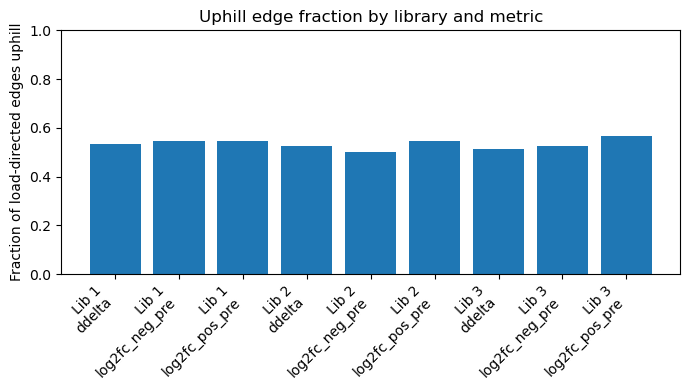

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

plot_df = uphill_edge_summary.copy()
x_labels = [
    f"Lib {row.library_id}\n{row.metric}"
    for row in plot_df.itertuples()
]

ax.bar(
    range(plot_df.shape[0]),
    plot_df["fraction_uphill"]
)

ax.set_xticks(range(plot_df.shape[0]))
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("Fraction of load-directed edges uphill")
ax.set_title("Uphill edge fraction by library and metric")
ax.set_ylim(0, 1)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "uphill_edge_fraction_by_library_metric.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
ddelta_uphill_edges = uphill_edges.query(
    "metric == 'ddelta' and is_uphill"
).copy()

graphs_by_library = {}

for library_id, sub_edges in ddelta_uphill_edges.groupby("library_id"):
    G = nx.DiGraph()
    
    library_landscape = landscape[landscape["library_id"] == library_id]
    
    for _, row in library_landscape.iterrows():
        G.add_node(
            row["wo"],
            mut_count=row["mut_count"],
            ddelta=row["ddelta"],
            log2fc_pos_pre=row["log2fc_pos_pre"],
            log2fc_neg_pre=row["log2fc_neg_pre"],
        )
    
    for _, edge in sub_edges.iterrows():
        G.add_edge(
            edge["source"],
            edge["target"],
            edge_delta=edge["edge_delta"],
        )
    
    graphs_by_library[library_id] = G
    
    print(
        f"Library {library_id}: "
        f"{G.number_of_nodes()} nodes, {G.number_of_edges()} uphill ddelta edges"
    )

Library 1: 256 nodes, 547 uphill ddelta edges
Library 2: 256 nodes, 538 uphill ddelta edges
Library 3: 256 nodes, 527 uphill ddelta edges


In [11]:
start_genotype = "WWWWWWWW"
end_genotype = "OOOOOOOO"

path_summary_rows = []

for library_id, G in graphs_by_library.items():
    has_start = start_genotype in G
    has_end = end_genotype in G
    has_path = nx.has_path(G, start_genotype, end_genotype) if has_start and has_end else False
    
    if has_path:
        shortest_path = nx.shortest_path(G, start_genotype, end_genotype)
        shortest_path_length = len(shortest_path) - 1
    else:
        shortest_path = None
        shortest_path_length = np.nan
    
    reachable_from_start = (
        nx.descendants(G, start_genotype)
        if has_start else set()
    )
    
    path_summary_rows.append({
        "library_id": library_id,
        "start_genotype": start_genotype,
        "end_genotype": end_genotype,
        "has_uphill_path_start_to_end": has_path,
        "shortest_uphill_path_length": shortest_path_length,
        "n_nodes_reachable_from_start": len(reachable_from_start),
        "shortest_path": " -> ".join(shortest_path) if shortest_path else "",
    })

path_reachability_summary = pd.DataFrame(path_summary_rows)

path_reachability_summary.to_csv(
    CHECKPOINT_DIR / "ddelta_uphill_path_reachability_summary.csv",
    index=False
)

path_reachability_summary

,library_id,start_genotype,end_genotype,has_uphill_path_start_to_end,shortest_uphill_path_length,n_nodes_reachable_from_start,shortest_path
0,1,WWWWWWWW,OOOOOOOO,False,NaN,18,
1,2,WWWWWWWW,OOOOOOOO,False,NaN,21,
2,3,WWWWWWWW,OOOOOOOO,False,NaN,13,


## Exhaustive W-to-O path scoring

Strictly uphill `ddelta` paths from `WWWWWWWW` to `OOOOOOOO` are absent in all three libraries. This section therefore evaluates all possible 8-step W-to-O mutation orders and scores each complete path by its `ddelta` edge changes.

For 8 binary positions, there are `8! = 40,320` possible complete W-to-O paths.

In [12]:
from itertools import permutations

def path_from_mutation_order(order: tuple[int, ...], start: str = "WWWWWWWW") -> list[str]:
    """
    Generate a W-to-O path by flipping positions in the specified order.
    
    Parameters
    ----------
    order:
        Tuple of zero-indexed positions to flip from W to O.
    
    start:
        Starting genotype. Defaults to all-W.
    """
    genotype = list(start)
    path = ["".join(genotype)]
    
    for pos in order:
        genotype[pos] = "O"
        path.append("".join(genotype))
    
    return path


all_orders = list(permutations(range(8)))
all_paths = [path_from_mutation_order(order) for order in all_orders]

assert len(all_paths) == 40320
assert all(path[0] == "WWWWWWWW" and path[-1] == "OOOOOOOO" for path in all_paths)
assert all(len(path) == 9 for path in all_paths)

print("Number of complete W-to-O paths:", len(all_paths))
all_paths[0]

Number of complete W-to-O paths: 40320


['WWWWWWWW',
 'OWWWWWWW',
 'OOWWWWWW',
 'OOOWWWWW',
 'OOOOWWWW',
 'OOOOOWWW',
 'OOOOOOWW',
 'OOOOOOOW',
 'OOOOOOOO']

In [13]:
def score_complete_paths(
    landscape_df: pd.DataFrame,
    metric: str = "ddelta"
) -> pd.DataFrame:
    """
    Score all complete W-to-O paths for each library using edge changes
    in the selected metric.
    """
    rows = []
    
    for library_id, sub in landscape_df.groupby("library_id"):
        value_map = sub.set_index("wo")[metric].to_dict()
        
        for path_id, path in enumerate(all_paths):
            edge_deltas = []
            
            for source, target in zip(path[:-1], path[1:]):
                edge_deltas.append(value_map[target] - value_map[source])
            
            edge_deltas = np.array(edge_deltas)
            
            rows.append({
                "library_id": library_id,
                "metric": metric,
                "path_id": path_id,
                "path": " -> ".join(path),
                "mutation_order_0_indexed": ",".join(map(str, all_orders[path_id])),
                "mutation_order_1_indexed": ",".join(str(i + 1) for i in all_orders[path_id]),
                "cumulative_edge_delta": edge_deltas.sum(),
                "mean_edge_delta": edge_deltas.mean(),
                "min_edge_delta": edge_deltas.min(),
                "max_edge_delta": edge_deltas.max(),
                "n_uphill_steps": int((edge_deltas > 0).sum()),
                "n_downhill_steps": int((edge_deltas <= 0).sum()),
                "edge_deltas": ",".join(f"{x:.6g}" for x in edge_deltas),
            })
    
    return pd.DataFrame(rows)


ddelta_path_scores = score_complete_paths(
    landscape,
    metric="ddelta"
)

ddelta_path_scores.to_csv(
    CHECKPOINT_DIR / "ddelta_complete_w_to_o_path_scores.csv",
    index=False
)

ddelta_path_scores.head()

,library_id,metric,path_id,path,mutation_order_0_indexed,mutation_order_1_indexed,cumulative_edge_delta,mean_edge_delta,min_edge_delta,max_edge_delta,n_uphill_steps,n_downhill_steps,edge_deltas
0,1,ddelta,0,WWWWWWWW -> OWWWWWWW -> OOWWWWWW -> OOOWWWWW -...,"0,1,2,3,4,5,6,7","1,2,3,4,5,6,7,8",0.272023,0.034003,-2.266088,4.258044,4,4,"-0.0579045,0.664397,-2.23344,1.60738,-2.21553,..."
1,1,ddelta,1,WWWWWWWW -> OWWWWWWW -> OOWWWWWW -> OOOWWWWW -...,"0,1,2,3,4,5,7,6","1,2,3,4,5,6,8,7",0.272023,0.034003,-2.266088,2.917507,4,4,"-0.0579045,0.664397,-2.23344,1.60738,-2.21553,..."
2,1,ddelta,2,WWWWWWWW -> OWWWWWWW -> OOWWWWWW -> OOOWWWWW -...,"0,1,2,3,4,6,5,7","1,2,3,4,5,7,6,8",0.272023,0.034003,-2.233435,2.793641,4,4,"-0.0579045,0.664397,-2.23344,1.60738,-2.21553,..."
3,1,ddelta,3,WWWWWWWW -> OWWWWWWW -> OOWWWWWW -> OOOWWWWW -...,"0,1,2,3,4,6,7,5","1,2,3,4,5,7,8,6",0.272023,0.034003,-2.233435,2.793641,4,4,"-0.0579045,0.664397,-2.23344,1.60738,-2.21553,..."
4,1,ddelta,4,WWWWWWWW -> OWWWWWWW -> OOWWWWWW -> OOOWWWWW -...,"0,1,2,3,4,7,5,6","1,2,3,4,5,8,6,7",0.272023,0.034003,-2.233435,1.855698,4,4,"-0.0579045,0.664397,-2.23344,1.60738,-2.21553,..."


In [14]:
cumulative_path_check = (
    ddelta_path_scores
    .groupby("library_id", as_index=False)
    .agg(
        n_unique_cumulative_scores=("cumulative_edge_delta", "nunique"),
        min_cumulative_score=("cumulative_edge_delta", "min"),
        max_cumulative_score=("cumulative_edge_delta", "max"),
    )
)

cumulative_path_check["max_minus_min"] = (
    cumulative_path_check["max_cumulative_score"] -
    cumulative_path_check["min_cumulative_score"]
)

cumulative_path_check.to_csv(
    CHECKPOINT_DIR / "ddelta_complete_path_cumulative_score_check.csv",
    index=False
)

cumulative_path_check

,library_id,n_unique_cumulative_scores,min_cumulative_score,max_cumulative_score,max_minus_min
0,1,32,0.272023,0.272023,2.664535e-15
1,2,33,0.312752,0.312752,2.664535e-15
2,3,24,0.963355,0.963355,3.108624e-15


Because the complete paths all share the same start and end genotypes, the cumulative sum of `ddelta` edge changes is path-independent up to floating-point precision. Therefore, complete paths are compared using bottleneck behavior and number of uphill steps rather than cumulative edge score.

In [15]:
best_path_rows = []

for library_id, sub in ddelta_path_scores.groupby("library_id"):
    best_bottleneck = sub.sort_values(
        ["min_edge_delta", "cumulative_edge_delta", "n_uphill_steps"],
        ascending=[False, False, False]
    ).iloc[0]
    
    max_uphill_steps = sub.sort_values(
        ["n_uphill_steps", "min_edge_delta", "cumulative_edge_delta"],
        ascending=[False, False, False]
    ).iloc[0]
    
    for label, row in [
        ("best_bottleneck", best_bottleneck),
        ("max_uphill_steps", max_uphill_steps),
    ]:
        best_path_rows.append({
            "library_id": library_id,
            "path_type": label,
            "path_id": int(row["path_id"]),
            "cumulative_edge_delta": row["cumulative_edge_delta"],
            "mean_edge_delta": row["mean_edge_delta"],
            "min_edge_delta": row["min_edge_delta"],
            "max_edge_delta": row["max_edge_delta"],
            "n_uphill_steps": int(row["n_uphill_steps"]),
            "n_downhill_steps": int(row["n_downhill_steps"]),
            "mutation_order_1_indexed": row["mutation_order_1_indexed"],
            "path": row["path"],
            "edge_deltas": row["edge_deltas"],
        })

best_path_summary = pd.DataFrame(best_path_rows)

best_path_summary.to_csv(
    CHECKPOINT_DIR / "ddelta_best_w_to_o_path_summary.csv",
    index=False
)

best_path_summary

,library_id,path_type,path_id,cumulative_edge_delta,mean_edge_delta,min_edge_delta,max_edge_delta,n_uphill_steps,n_downhill_steps,mutation_order_1_indexed,path,edge_deltas
0,1,best_bottleneck,926,0.272023,0.034003,-0.407798,0.515161,4,4,"1,3,4,7,6,5,2,8",WWWWWWWW -> OWWWWWWW -> OWOWWWWW -> OWOOWWWW -...,"-0.0579045,-0.299017,-0.2622,0.422023,0.250641..."
1,1,max_uphill_steps,33273,0.272023,0.034003,-1.001795,0.483404,7,1,"7,5,2,3,4,6,8,1",WWWWWWWW -> WWWWWWOW -> WWWWOWOW -> WOWWOWOW -...,"0.483404,0.19827,0.0959935,0.050659,0.119321,0..."
2,2,best_bottleneck,34392,0.312752,0.039094,-0.283563,0.884134,3,5,"7,6,5,4,1,2,3,8",WWWWWWWW -> WWWWWWOW -> WWWWWOOW -> WWWWOOOW -...,"0.177313,-0.0273705,-0.283563,-0.271728,0.2978..."
3,2,max_uphill_steps,31562,0.312752,0.039094,-1.173139,0.353278,7,1,"7,2,8,1,3,5,4,6",WWWWWWWW -> WWWWWWOW -> WOWWWWOW -> WOWWWWOO -...,"0.177313,0.344483,0.108231,-1.17314,0.0641184,..."
4,3,best_bottleneck,25849,0.963355,0.120419,-0.256076,1.258760,4,4,"6,1,8,4,2,3,7,5",WWWWWWWW -> WWWWWOWW -> OWWWWOWW -> OWWWWOWO -...,"-0.214556,0.0961498,0.0250381,-0.256076,-0.186..."
5,3,max_uphill_steps,6692,0.963355,0.120419,-1.758192,1.233992,7,1,"2,4,3,7,8,5,1,6",WWWWWWWW -> WOWWWWWW -> WOWOWWWW -> WOOOWWWW -...,"0.375294,0.404879,-1.75819,0.0626435,0.300746,..."


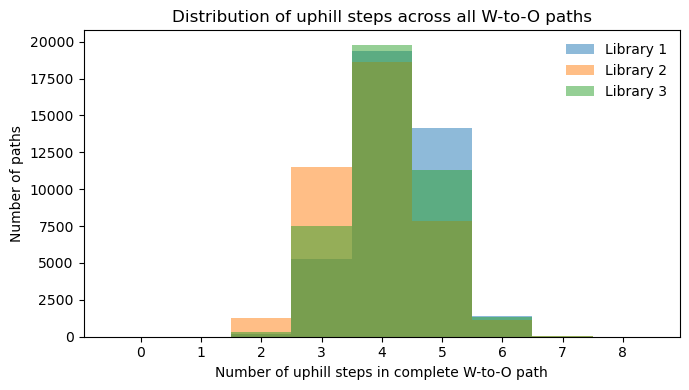

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

plot_df = ddelta_path_scores.copy()

for library_id, sub in plot_df.groupby("library_id"):
    ax.hist(
        sub["n_uphill_steps"],
        bins=np.arange(-0.5, 8.6, 1),
        alpha=0.5,
        label=f"Library {library_id}"
    )

ax.set_xlabel("Number of uphill steps in complete W-to-O path")
ax.set_ylabel("Number of paths")
ax.set_title("Distribution of uphill steps across all W-to-O paths")
ax.set_xticks(range(9))
ax.legend(frameon=False)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "ddelta_complete_path_uphill_step_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
archive_dir = PROJECT_ROOT / "archive" / "landscape_figures_analysis"

path_files = sorted(archive_dir.glob("*path*"))

for path in path_files:
    print(path.name)

best_path_analysis_ddelta.py
best_path_analysis_ddelta_all_directed_edges.csv
best_path_analysis_ddelta_filtered_edges.csv
best_path_analysis_ddelta_max_bottleneck_path_edges.csv
best_path_analysis_ddelta_max_bottleneck_path_nodes.txt
best_path_analysis_ddelta_max_cumulative_path_edges.csv
best_path_analysis_ddelta_max_cumulative_path_nodes.txt
best_path_analysis_ddelta_summary.csv
ddelta_path_diagnostics.py
ddelta_path_diagnostics_best_partial_path_edges.csv
ddelta_path_diagnostics_best_partial_path_nodes.txt
ddelta_path_diagnostics_end_incoming_all.csv
ddelta_path_diagnostics_end_incoming_filtered.csv
ddelta_path_diagnostics_furthest_reachable_nodes.csv
ddelta_path_diagnostics_reachable_nodes.csv
ddelta_path_diagnostics_start_outgoing_all.csv
ddelta_path_diagnostics_start_outgoing_filtered.csv
ddelta_path_diagnostics_summary.csv
weighted_optimal_path_ddelta.py
weighted_optimal_path_ddelta_all_directed_edges.csv
weighted_optimal_path_ddelta_optimal_path_edges.csv
weighted_optimal_path

In [18]:
candidate_summary_files = [
    "best_path_analysis_ddelta_summary.csv",
    "weighted_optimal_path_ddelta_summary.csv",
    "ddelta_path_diagnostics_summary.csv",
]

for filename in candidate_summary_files:
    path = archive_dir / filename
    if path.exists():
        print(f"\n--- {filename} ---")
        display(pd.read_csv(path))
    else:
        print(f"\nMissing: {filename}")


--- best_path_analysis_ddelta_summary.csv ---


,n_total_directed_one_step_edges,n_filtered_uphill_repro_edges,fraction_filtered,reproducibility_threshold,sd_floor,sum_path_exists,sum_path_score,sum_path_length,bottleneck_path_exists,bottleneck_path_score,bottleneck_path_length
0,1024,172,0.167969,0.3,0.1,False,NaN,NaN,False,NaN,NaN



--- weighted_optimal_path_ddelta_summary.csv ---


,start,end,path_exists,path_length,cumulative_weighted_score,n_positive_steps,n_nonnegative_steps,n_negative_steps,minimum_step_effect_on_path,mean_step_effect_on_path,mean_log_reproducibility_on_path,sd_floor,score_definition
0,WWWWWWWW,OOOOOOOO,True,8,2.913957,3,3,5,-2.138545,0.064505,0.399581,0.1,mean_step * log10(|mean_step|/(SD + floor) + 1)



--- ddelta_path_diagnostics_summary.csv ---


,n_total_directed_edges,n_filtered_uphill_repro_edges,fraction_filtered,reproducibility_threshold,n_outgoing_from_start_all,n_outgoing_from_start_filtered,n_incoming_to_end_all,n_incoming_to_end_filtered,n_reachable_nodes_from_start,max_reachable_mut_load,best_partial_target,best_partial_target_mut_load,best_partial_target_hamming_to_end,best_partial_sum_score,full_path_exists
0,1024,172,0.167969,0.3,8,1,8,2,2,1,WWWWWWOW,1,7,0.145467,False


## Reproduce archived weighted optimal ddelta path

The archived path analysis contains several related outputs. The strict filtered-uphill/reproducible path analysis does not produce a complete path from `WWWWWWWW` to `OOOOOOOO`.

The dissertation-facing complete path appears to correspond to the archived weighted optimal path analysis, which allows a full W-to-O path and scores directed edges using:

`mean_step * log10(|mean_step| / (SD + floor) + 1)`

This section reproduces that weighted optimal path calculation.

In [19]:
# Compute load-directed ddelta edge effects for each library, then summarize
# mean and standard deviation across libraries.

ddelta_edges_by_library = uphill_edges.query("metric == 'ddelta'").copy()

edge_stats = (
    ddelta_edges_by_library
    .groupby(["source", "target"], as_index=False)
    .agg(
        mean_step=("edge_delta", "mean"),
        sd_step=("edge_delta", "std"),
        n_libraries=("library_id", "nunique")
    )
)

sd_floor = 0.1

edge_stats["weighted_score"] = (
    edge_stats["mean_step"] *
    np.log10(np.abs(edge_stats["mean_step"]) / (edge_stats["sd_step"] + sd_floor) + 1)
)

edge_stats["is_positive_mean_step"] = edge_stats["mean_step"] > 0
edge_stats["is_nonnegative_mean_step"] = edge_stats["mean_step"] >= 0

edge_stats.to_csv(
    CHECKPOINT_DIR / "weighted_optimal_path_ddelta_all_directed_edges_recalculated.csv",
    index=False
)

edge_stats.head()

,source,target,mean_step,sd_step,n_libraries,weighted_score,is_positive_mean_step,is_nonnegative_mean_step
0,OOOOOOOW,OOOOOOOO,0.995568,1.512331,3,0.207911,True,True
1,OOOOOOWO,OOOOOOOO,0.734510,1.382966,3,0.128339,True,True
2,OOOOOOWW,OOOOOOOW,2.682607,2.934830,3,0.737897,True,True
3,OOOOOOWW,OOOOOOWO,2.943666,0.161246,3,3.204967,True,True
4,OOOOOWOO,OOOOOOOO,0.615253,0.799256,3,0.139286,True,True


In [20]:
# Build a directed graph using weighted edge scores.

weighted_G = nx.DiGraph()

for genotype in genotypes:
    weighted_G.add_node(
        genotype,
        mut_count=mut_count(genotype)
    )

for _, row in edge_stats.iterrows():
    weighted_G.add_edge(
        row["source"],
        row["target"],
        weight=row["weighted_score"],
        mean_step=row["mean_step"],
        sd_step=row["sd_step"],
    )

start_genotype = "WWWWWWWW"
end_genotype = "OOOOOOOO"

assert nx.is_directed_acyclic_graph(weighted_G), "Expected load-directed graph to be a DAG."

# Dynamic programming over nodes sorted by mutational load.
topological_nodes = sorted(
    weighted_G.nodes,
    key=lambda g: mut_count(g)
)

best_score = {node: -np.inf for node in weighted_G.nodes}
best_previous = {node: None for node in weighted_G.nodes}

best_score[start_genotype] = 0.0

for node in topological_nodes:
    if best_score[node] == -np.inf:
        continue
    
    for successor in weighted_G.successors(node):
        edge_weight = weighted_G.edges[node, successor]["weight"]
        candidate_score = best_score[node] + edge_weight
        
        if candidate_score > best_score[successor]:
            best_score[successor] = candidate_score
            best_previous[successor] = node

path_exists = best_score[end_genotype] > -np.inf

if path_exists:
    path = []
    current = end_genotype
    
    while current is not None:
        path.append(current)
        current = best_previous[current]
    
    optimal_path = list(reversed(path))
else:
    optimal_path = []

optimal_path_score = best_score[end_genotype]

print("Path exists:", path_exists)
print("Optimal path length:", len(optimal_path) - 1 if optimal_path else np.nan)
print("Cumulative weighted score:", optimal_path_score)
print("Path:")
print(" -> ".join(optimal_path))

Path exists: True
Optimal path length: 8
Cumulative weighted score: 2.9139567889737714
Path:
WWWWWWWW -> WWWWOWWW -> WWWOOWWW -> OWWOOWWW -> OWWOOOWW -> OOWOOOWW -> OOOOOOWW -> OOOOOOWO -> OOOOOOOO


In [21]:
# Summarize weighted optimal path and compare against archived summary.

optimal_path_edges = []

for source, target in zip(optimal_path[:-1], optimal_path[1:]):
    edge_data = weighted_G.edges[source, target]
    
    optimal_path_edges.append({
        "source": source,
        "target": target,
        "source_mut_count": mut_count(source),
        "target_mut_count": mut_count(target),
        "mean_step": edge_data["mean_step"],
        "sd_step": edge_data["sd_step"],
        "weighted_score": edge_data["weight"],
    })

optimal_path_edges = pd.DataFrame(optimal_path_edges)

weighted_path_summary_recalc = pd.DataFrame([{
    "start": start_genotype,
    "end": end_genotype,
    "path_exists": path_exists,
    "path_length": len(optimal_path) - 1 if optimal_path else np.nan,
    "cumulative_weighted_score": optimal_path_edges["weighted_score"].sum() if path_exists else np.nan,
    "n_positive_steps": int((optimal_path_edges["mean_step"] > 0).sum()) if path_exists else np.nan,
    "n_nonnegative_steps": int((optimal_path_edges["mean_step"] >= 0).sum()) if path_exists else np.nan,
    "n_negative_steps": int((optimal_path_edges["mean_step"] < 0).sum()) if path_exists else np.nan,
    "minimum_step_effect_on_path": optimal_path_edges["mean_step"].min() if path_exists else np.nan,
    "mean_step_effect_on_path": optimal_path_edges["mean_step"].mean() if path_exists else np.nan,
    "mean_log_reproducibility_on_path": (
        np.log10(
            np.abs(optimal_path_edges["mean_step"]) /
            (optimal_path_edges["sd_step"] + sd_floor) + 1
        ).mean()
        if path_exists else np.nan
    ),
    "sd_floor": sd_floor,
    "score_definition": "mean_step * log10(|mean_step|/(SD + floor) + 1)",
}])

weighted_path_summary_recalc.to_csv(
    CHECKPOINT_DIR / "weighted_optimal_path_ddelta_summary_recalculated.csv",
    index=False
)

optimal_path_edges.to_csv(
    CHECKPOINT_DIR / "weighted_optimal_path_ddelta_optimal_path_edges_recalculated.csv",
    index=False
)

with open(CHECKPOINT_DIR / "weighted_optimal_path_ddelta_optimal_path_nodes_recalculated.txt", "w") as f:
    f.write("\n".join(optimal_path))

weighted_path_summary_recalc

,start,end,path_exists,path_length,cumulative_weighted_score,n_positive_steps,n_nonnegative_steps,n_negative_steps,minimum_step_effect_on_path,mean_step_effect_on_path,mean_log_reproducibility_on_path,sd_floor,score_definition
0,WWWWWWWW,OOOOOOOO,True,8,2.913957,3,3,5,-2.138545,0.064505,0.399581,0.1,mean_step * log10(|mean_step|/(SD + floor) + 1)


In [22]:
# Compare recalculated weighted optimal path summary against archived output.

archived_weighted_summary = pd.read_csv(
    archive_dir / "weighted_optimal_path_ddelta_summary.csv"
)

comparison_cols = [
    "path_exists",
    "path_length",
    "cumulative_weighted_score",
    "n_positive_steps",
    "n_nonnegative_steps",
    "n_negative_steps",
    "minimum_step_effect_on_path",
    "mean_step_effect_on_path",
    "mean_log_reproducibility_on_path",
]

weighted_summary_comparison = archived_weighted_summary[comparison_cols].merge(
    weighted_path_summary_recalc[comparison_cols],
    left_index=True,
    right_index=True,
    suffixes=("_archived", "_recalculated")
)

weighted_summary_comparison

,path_exists_archived,path_length_archived,cumulative_weighted_score_archived,n_positive_steps_archived,n_nonnegative_steps_archived,n_negative_steps_archived,minimum_step_effect_on_path_archived,mean_step_effect_on_path_archived,mean_log_reproducibility_on_path_archived,path_exists_recalculated,path_length_recalculated,cumulative_weighted_score_recalculated,n_positive_steps_recalculated,n_nonnegative_steps_recalculated,n_negative_steps_recalculated,minimum_step_effect_on_path_recalculated,mean_step_effect_on_path_recalculated,mean_log_reproducibility_on_path_recalculated
0,True,8,2.913957,3,3,5,-2.138545,0.064505,0.399581,True,8,2.913957,3,3,5,-2.138545,0.064505,0.399581


In [23]:
weighted_summary_difference_rows = []

for col in comparison_cols:
    archived_col = f"{col}_archived"
    recalculated_col = f"{col}_recalculated"
    
    archived_value = weighted_summary_comparison.loc[0, archived_col]
    recalculated_value = weighted_summary_comparison.loc[0, recalculated_col]
    
    if isinstance(archived_value, (int, float, np.integer, np.floating, bool)):
        difference = recalculated_value - archived_value
    else:
        difference = None
    
    weighted_summary_difference_rows.append({
        "metric": col,
        "archived": archived_value,
        "recalculated": recalculated_value,
        "difference": difference,
    })

weighted_summary_difference = pd.DataFrame(weighted_summary_difference_rows)

weighted_summary_difference.to_csv(
    CHECKPOINT_DIR / "weighted_optimal_path_ddelta_summary_comparison.csv",
    index=False
)

weighted_summary_difference

,metric,archived,recalculated,difference
0,path_exists,True,True,NaN
1,path_length,8,8,0.000000e+00
2,cumulative_weighted_score,2.913957,2.913957,-4.440892e-16
3,n_positive_steps,3,3,0.000000e+00
4,n_nonnegative_steps,3,3,0.000000e+00
5,n_negative_steps,5,5,0.000000e+00
6,minimum_step_effect_on_path,-2.138545,-2.138545,0.000000e+00
7,mean_step_effect_on_path,0.064505,0.064505,1.387779e-16
8,mean_log_reproducibility_on_path,0.399581,0.399581,5.551115e-17


## Network/path analysis summary

This notebook reconstructs the W/O genotype network as an 8-dimensional hypercube and reproduces the dissertation-associated weighted optimal `ddelta` path calculation.

Generated outputs include:

- undirected one-step W/O genotype edge list
- load-directed genotype edge list
- uphill edge tables for `log2fc_pos_pre`, `log2fc_neg_pre`, and `ddelta`
- uphill edge summary statistics
- `ddelta` uphill directed graphs by library
- start-to-end strict-uphill `ddelta` path reachability summaries
- exhaustive complete W-to-O path diagnostics
- cumulative path-score sanity check
- archived path-analysis file previews
- recalculated weighted optimal `ddelta` path
- archived-vs-recalculated weighted optimal path comparison

The strict-uphill `ddelta` path analysis does not produce a full path from `WWWWWWWW` to `OOOOOOOO`.

For complete W-to-O paths, the cumulative sum of unweighted `ddelta` edge changes is path-independent up to floating-point precision because all paths share the same start and end genotypes. Therefore, the diagnostic complete-path comparisons emphasize bottleneck behavior and number of uphill steps rather than cumulative unweighted edge score.

The dissertation-associated complete path corresponds to the weighted optimal path analysis, which uses the archived score definition:

`mean_step * log10(|mean_step| / (SD + floor) + 1)`

The recalculated weighted optimal path summary matches the archived dissertation-associated output.